# Precision functional mapping

Infomap algorithm
(Gordon 2017)

Networks were defined in each individual by collapsing across density thresholds (Laumann et al., 2015) and assigning identities based on similarity to a set of template networks (Figure S3A).

- cross-correlation matrix: of the time courses from all brain vertices (voxels for sucortical regions)
- spatial exclusion: Correlations between vertices/voxels within 30 mm of each other were set to zero in this matrix to avoid basing network membership on correlations attributable to spatial smoothing (Geodesic distance was used for within-hemisphere surface connections)
- thresholded: at a range of values calculated based on the resulting density of the matrix; the density thresholds ranged from 0.3% to 5%
- Infomap algorithm: calculated community assignments (representing brain networks) separately for each threshold. Small networks with 400 or fewer vertices were considered unassigned and removed from further consideration

--> 

- network identity assignment: At each density threshold, all identified communities within an individual were compared (using spatial overlap, quantified with the Jaccard index) to each one of the independent group networks in turn. The best-matching (highest-overlap) community was assigned that network identity; that community was not considered for comparison with other networks within that threshold.
    * Jaccard index measures similarity between finite non-empty sample sets and is defined as the size of the intersection divided by the size of the union of the sample sets

- contiguous network pieces that were smaller than 30 mm2 were removed,



### State
sub-average
- add sucortical regions to have network assignment as previously described? ()
- N_nets changes with the `thresh_conn` & `preferred_number_of_modules`
--> but lowering conn_threshold (for sub-average 0.1) gives more networks! (more similar to as previously described?)
- add sucortical regions? 

### Plans:
--> network identity assignment
- dorsal attention/fronto parietal network in NPC regions? how much surface area?

Explanations:
Laumann 2015: the presence of a primary visual system and the lack of the ventral (/lateral) somato-motor system might relate to a difference in eye state between the individual (eyes closed) and group (eyes open) data.

In [1]:
import nilearn
import numpy as np
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
from brainspace.utils.parcellation import map_to_labels

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [ ]:
# individual subject
sub ='01'
source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo') # .parcel
confspec = '32Pscrub3BPfilter'
cm_file = op.join(source_folder,f'sub-{sub}_ses-1_task-magjudge_confspec-{confspec}runFD104-6runs_CM-unfiltered.npy')
cm_f = np.load(cm_file)

#cm_cc_mask = op.join(bids_folder, 'derivatives',f'gradients.{confspec}runFD104', f'sub-{sub}', f'sub-{sub}_cc-mask_space-fsaverag5.npy')
#cm_cc_mask = np.load(cm_cc_mask)
#cm_filtered = cm_f[cm_cc_mask, :][:, cm_cc_mask]


In [2]:
# sub-average
sub = 'average'
source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo') # .parcel
confspec = '36Pscrub3BPfilter'
cm_file = op.join(source_folder,f'cm_av_ses-1_fsav5_unfiltered_confspec-{confspec}runFD104.npy')
cm_f = np.load(cm_file)


In [3]:
from nilearn import datasets

atlas = datasets.fetch_atlas_surf_destrieux()
masked_labels = [atlas['labels'].index(r) for r in [b'Medial_wall', b'Unknown']]

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [4]:
mask_hemi_L = ~np.isin(atlas['map_left'], masked_labels)
mask_hemi_R = ~np.isin(atlas['map_right'], masked_labels)

geo_dist_L = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-lh.npy'))
geo_dist_L = geo_dist_L[np.ix_(mask_hemi_L, mask_hemi_L)]

geo_dist_R = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-rh.npy'))
geo_dist_R = geo_dist_R[np.ix_(mask_hemi_R, mask_hemi_R)]

N_nodes_hemi_L  = mask_hemi_L.sum()
cm_hemi_L = cm_f[:N_nodes_hemi_L, :N_nodes_hemi_L]  
cm_hemi_R = cm_f[N_nodes_hemi_L:, N_nodes_hemi_L:]

# spatial exclusion mask
distance_threshold = 30.0  # in mm
cm_hemi_L[geo_dist_L < distance_threshold] = 0
cm_hemi_R[geo_dist_R < distance_threshold] = 0

In [5]:
# dedice on hemisphere
hemi = 'R'# 'both' 'L' or 'R'
cm_hemi = cm_hemi_L if hemi == 'L' else cm_hemi_R

In [23]:
# or both together ?
hemi = 'both'
cm_total = cm_f.copy()

# replace within hemisphere matrices with the spatially filtered ones
cm_total[:N_nodes_hemi_L, :N_nodes_hemi_L] = cm_hemi_L
cm_total[N_nodes_hemi_L:, N_nodes_hemi_L:] = cm_hemi_R

# ?? so far 'both' does not work... --> triangular mesh modules....

In [35]:
# Threshold matrix
# recheck code!

conn_matrix = cm_total if hemi == 'both' else cm_hemi
thresh_conn = 0.1  # Proportion of connections to keep

def threshold_matrix(mat, proportion=thresh_conn):
    n = mat.shape[0]
    mat = mat.copy()
    np.fill_diagonal(mat, 0)     # Remove diagonal

    thresh = np.percentile(mat[mat > 0], 100 - 100 * proportion)     # Find threshold value
    mat[mat < thresh] = 0
    return mat

conn_thresh = threshold_matrix(conn_matrix)

In [30]:
print(sub, hemi, thresh_conn)
#sns.heatmap(conn_thresh, cmap='viridis', square=True, cbar_kws={"shrink": .8})

average both 0.5


In [36]:
from infomap import Infomap

mat = conn_thresh
preferred_number_of_modules = 15  # Set your preferred number of modules here

N = mat.shape[0]
im = Infomap(preferred_number_of_modules=preferred_number_of_modules) # add flags like '--two-level' if needed

for i in range(N):
    for j in range(i+1, N):
        w = mat[i, j]
        if w > 0:
            im.add_link(i, j, w)
im.run()

modules = [[node.node_id, node.module_id] for node in im.nodes] # #modules = {node.node_id: node.module_id for node in im.nodes}
print(np.unique(np.array(modules)[:,1]))
print(len(np.unique(np.array(modules)[:,1])))
print(np.array(modules)[:,1].shape)

  Infomap v2.8.0 starts at 2025-07-14 12:42:00
  -> Input network: 
  -> No file output!
  -> Configuration: preferred-number-of-modules = 15
  OpenMP 201511 detected with 16 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 18094 nodes and 7864531 links...
  -> One-level codelength: 13.773135

Trial 1/1 starting at 2025-07-14 12:42:05
Two-level compression: 9.2% 0.24% 0.186236374% 0.0648767055% 
Partitioned to codelength 0.63676115 + 11.8136801 + 0 = 12.4504412 in 15 modules.

Recursive sub-structure compression: 0% . Found 2 levels with codelength 12.4504412

=> Trial 1/1 finished in 47.0551254s with codelength 12.4504412


Summary after 1 trial
Best end modular solution in 2 levels:
Per level number of modules:         [         15,           0] (sum: 15)
Per level number of leaf 

In [40]:
# save
all_nodes = np.arange(N)
returned_nodes = np.array([node.node_id for node in im.nodes])
returned_modules = np.array([node.module_id for node in im.nodes])

# Fill in missing
full_module_mapping = np.full((N,), -1, dtype=int)  # -1 means unassigned
full_module_mapping[returned_nodes] = returned_modules

module_mapping = np.stack([all_nodes, full_module_mapping], axis=1)
print(module_mapping.shape)

#module_mapping = np.array(modules) # np.array(modules)[:,1]
#np.save(op.join(bids_folder,'derivatives','networks_infomap', f'sub-{sub}_module_mapping_infomap_hemi-{hemi}_thresh-{thresh_conn}.npy'), module_mapping)

(18715, 2)


In [43]:
# both hemis
hemi_to_plot = 'R'
i = 0 if hemi_to_plot == 'L' else 1

if hemi == 'both':
    #module_mapping = np.array(modules)
    module_mapping.shape

    modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
    modules_fsav5[mask] = module_mapping[:,1]
    print(modules_fsav5.shape)

    # modules got from run infomap on both, but plot only one hemi
    modules_fsav5_hemi = np.split(modules_fsav5,2)[i]
    modules_fsav5_hemi.shape
    print("Number of NaNs in Z:", np.isnan(modules_fsav5_hemi).sum())
    print("Number of Infs in Z:", np.isinf(modules_fsav5_hemi).sum())

else:
    mask_hemi = mask_hemi_L if hemi == 'L' else mask_hemi_R
    modules_fsav5_hemi = np.full(mask_hemi.shape[0], np.nan, dtype=float)
    modules_fsav5_hemi[mask_hemi] = module_mapping[:, 1]

(20484,)
Number of NaNs in Z: 881
Number of Infs in Z: 0


#### Plot

In [44]:
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt 
fsaverage = fetch_surf_fsaverage('fsaverage5') 
views = ['medial','lateral','dorsal','posterior']
cmap = 'Paired'#''viridis' # 


Text(0.5, 0.75, 'sub average, hemi both \n thresh 0.1')

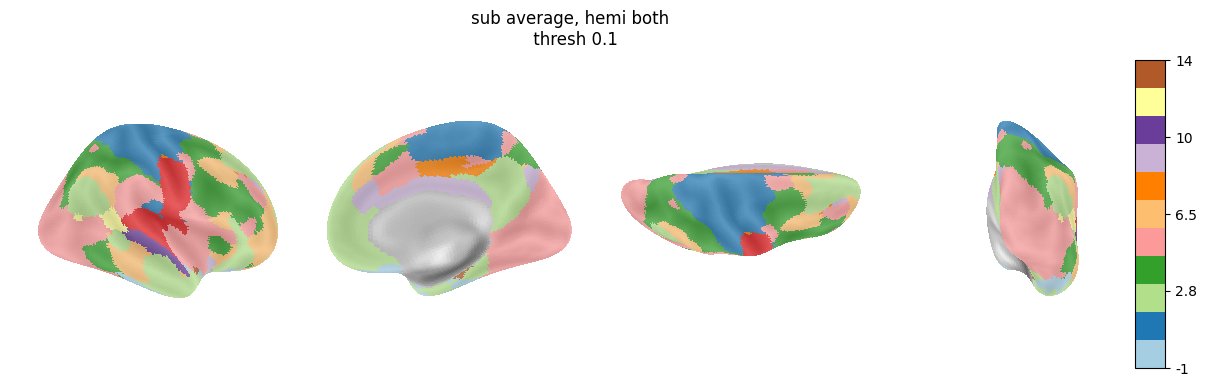

In [45]:
#hemi = 'L' # 'lh' or 'rh'

map = modules_fsav5_hemi

hemi_to_plot = hemi if hemi != 'both' else hemi_to_plot
surf_mesh = fsaverage.infl_right if hemi_to_plot =='R' else fsaverage.infl_left
bg_map = fsaverage.sulc_right if hemi_to_plot =='R' else fsaverage.sulc_left

figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
for i,view in enumerate(views):
    colbar = True if view == 'posterior' else False
    nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, avg_method = 'median',# infl_right # pial_right
            view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
            bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
figure.subplots_adjust(wspace=0.01)
figure.suptitle(f'sub {sub}, hemi {hemi} \n thresh {thresh_conn}', y=0.75)

Laumann 2015: the presence of a primary visual system and the lack of the ventral (/lateral) somato-motor system might relate to a difference in eye state between the individual (eyes closed) and group (eyes open) data.

# OLD

## Both hemispheres at the same time


In [ ]:
mask_hemi_L = ~np.isin(atlas['map_left'], masked_labels)
mask_hemi_R = ~np.isin(atlas['map_right'], masked_labels)

geo_dist_L = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-lh.npy'))
geo_dist_L = geo_dist[np.ix_(mask_hemi_L, mask_hemi_L)]

geo_dist_R = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-rh.npy'))
geo_dist_R = geo_dist[np.ix_(mask_hemi_R, mask_hemi_R)]

N_nodes_hemi_L  = mask_hemi_L.sum()

cm_hemi_L = cm_f[:N_nodes_hemi_L, :N_nodes_hemi_L]  
cm_hemi_R = cm_f[N_nodes_hemi_L:, N_nodes_hemi_L:]

# spatial exclusion mask
distance_threshold = 30.0  # in mm
cm_hemi_L[geo_dist_L < distance_threshold] = 0
cm_hemi_R[geo_dist_R < distance_threshold] = 0

cm_total = cm_f.copy()
cm_total[:N_nodes_hemi_L, :N_nodes_hemi_L] = cm_hemi_L
cm_total[N_nodes_hemi_L:, N_nodes_hemi_L:] = cm_hemi_R

In [144]:
conn_matrix = cm_total.copy()
thresh_conn = 0.3  # Proportion of connections to keep

def threshold_matrix(mat, proportion=thresh_conn):
    n = mat.shape[0]
    mat = mat.copy()
    np.fill_diagonal(mat, 0)     # Remove diagonal

    thresh = np.percentile(mat[mat > 0], 100 - 100 * proportion)     # Find threshold value
    mat[mat < thresh] = 0
    return mat

conn_thresh = threshold_matrix(conn_matrix)

In [145]:
from infomap import Infomap

mat = conn_thresh
preferred_number_of_modules = 10  # Set your preferred number of modules here

N = mat.shape[0]
im = Infomap(preferred_number_of_modules=preferred_number_of_modules)  # add flags like '--two-level' if needed

for i in range(N):
    for j in range(i+1, N):
        w = mat[i, j]
        if w > 0:
            im.add_link(i, j, w)
im.run()

modules = [[node.node_id, node.module_id] for node in im.nodes] # #modules = {node.node_id: node.module_id for node in im.nodes}

print(np.unique(np.array(modules)[:,1]))

  Infomap v2.8.0 starts at 2025-07-08 15:07:11
  -> Input network: 
  -> No file output!
  OpenMP 201511 detected with 16 threads...
  -> Ordinary network input, using the Map Equation for first order network flows
Calculating global network flow using flow model 'undirected'... 
  -> Using undirected links.
  => Sum node flow: 1, sum link flow: 1
Build internal network with 18715 nodes and 23599100 links...
  -> One-level codelength: 13.9831039

Trial 1/1 starting at 2025-07-08 15:07:33
Two-level compression: 4.9% 0.69% 
Partitioned to codelength 0.386746843 + 12.8150778 = 13.2018246 in 8 (6 non-trivial) modules.
Super-level compression: to codelength 13.2018246 in 8 top modules.

Recursive sub-structure compression: 0% . Found 2 levels with codelength 13.2018246

=> Trial 1/1 finished in 121.142293s with codelength 13.2018246


Summary after 1 trial
Best end modular solution in 2 levels:
Per level number of modules:         [          8,           0] (sum: 8)
Per level number of leaf

In [173]:
module_mapping = np.array(modules)
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = module_mapping[:,1]


/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/plotting/surf_plotting.py:582: RuntimeWarning: invalid value encountered in divide
  data_copy /= vmax - vmin
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/matplotlib/colorbar.py:1223: RuntimeWarning: invalid value encountered in divide
  y = y / (self._boundaries[self._inside][-1] -
/home/ubuntu/miniconda3/envs/numrefields/lib/python3.10/site-packages/nilearn/plotting/surf_plotting.py:712: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  figure.colorbar(


ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

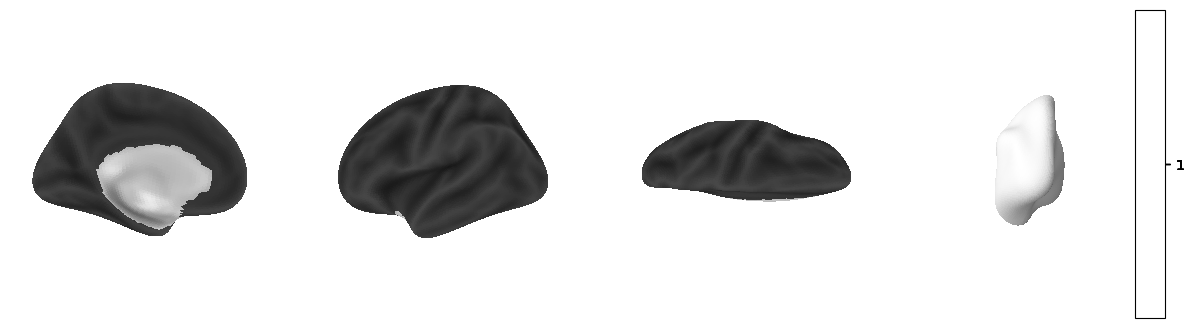

In [174]:
# plot both hemispheres

surf_map = modules_fsav5

for i, hemi in enumerate(['L','R']):
    map = np.split(surf_map,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    #figure.suptitle(f'{cm_name}, grad {n_grad+1}', y=0.75)

In [ ]:
# Old for individual subs

from numrisk.fmri_analysis.gradients.utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()
mask[mask == True] = cm_cc_mask 

module_mapping = np.array(modules)

# Use -1 as fill value instead of np.nan since module IDs are integers
modules_fsav5 = map_to_labels(module_mapping[:,1], labeling_noParcel, mask=mask, fill=-1)

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


In [ ]:
# plot both hemispheres

surf_map = modules_fsav5

for i, hemi in enumerate(['L','R']):
    map = np.split(surf_map,2)[i]
    surf_mesh = fsaverage.infl_right if hemi =='R' else fsaverage.infl_left
    bg_map = fsaverage.sulc_right if hemi =='R' else fsaverage.sulc_left

    figure, axes = plt.subplots(nrows=1, ncols=len(views),figsize = (15,8), subplot_kw=dict(projection='3d'))
    for i,view in enumerate(views):
        colbar = True if view == 'posterior' else False
        nplt.plot_surf(surf_mesh=surf_mesh , surf_map= map, # infl_right # pial_right
                view= view,cmap=cmap, colorbar=colbar, #title=f'sub-{sub}, grad {n_grad+1}',
                bg_map=bg_map, bg_on_data=True,darkness=0.7, axes=axes[i]) 
    figure.subplots_adjust(wspace=0.01)
    #figure.suptitle(f'{cm_name}, grad {n_grad+1}', y=0.75)

## Additional 

In [ ]:
# geodesic distances

import gdist

hemi = 'rh' # 'lh'  # or for right hemisphere
fsav5_fs_dir = '/mnt_03/ds-dnumrisk/derivatives/freesurfer/fsaverage5'
surf_path = op.join(fsav5_fs_dir, 'surf', f'{hemi}.pial')
coords, faces = nib.freesurfer.read_geometry(surf_path)
faces = faces.astype(np.int32)

# Choose N vertices to compute pairwise geodesic distances
N = coords.shape[0]

# Preallocate distance matrix
geo_dist = np.zeros((N, N), dtype=np.float32)

# Compute distance from each vertex to all others
for i in range(N):
    source = np.array([i], dtype=np.int32)
    distances = gdist.compute_gdist(
        coords.astype(np.float64),
        faces,
        source_indices=source,
    )
    geo_dist[i] = distances

source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo') # .parcel
np.save(op.join(source_folder, f'geo_dist_fsav5_hemi-{hemi}.npy'), geo_dist)

In [ ]:
# old

# load in geodesic distances
geo_dist_L = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-lh.npy'))
geo_dist_R = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-rh.npy'))

N_vertices_total = geo_dist_L.shape[0] + geo_dist_R.shape[0]
N_vertices_hemi = N_vertices_total //2 # N_vertices_hemi == N_vertices_total//2

geo_dist_total = np.full((N_vertices_total, N_vertices_total), 31) # no distance thresholding between hemispheres??
geo_dist_total[:N_vertices_hemi,:N_vertices_hemi] = geo_dist_L
geo_dist_total[N_vertices_hemi:,N_vertices_hemi:] = geo_dist_R

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

geo_dist_total = geo_dist_total[mask,mask]

# Apply spatial exclusion mask
distance_threshold = 30.0  # in mm
spatial_mask = geo_dist_total < distance_threshold

cm_total = cm_f.copy()
cm_total[spatial_mask] = 0